# 02 — Métodos de ensamble (Bagging, Boosting, RF, XGBoost, LightGBM, CatBoost)

**Módulo 2 · Algoritmos avanzados de ML (+ MLflow)**

Los **ensembles** combinan muchos aprendices *débiles* en uno *fuerte*. Vemos la
intuición de **bagging vs boosting**, la ponemos en práctica con
**`BaggingClassifier`** y un **Random Forest**, comparamos las tres librerías
modernas de gradient boosting —**XGBoost**, **LightGBM**, **CatBoost**—
explicando *en qué se diferencian*, y cerramos con los meta-ensembles de
scikit-learn: **`VotingClassifier`** y **`StackingClassifier`**. Todo se
registra en **MLflow** y el mejor modelo se guarda en el registry.


## 1. La visión sesgo–varianza de los ensembles

**Intuición:** promediar muchos modelos reduce la varianza, sobre todo si esos
modelos cometen errores *poco correlacionados*.

Si promediamos $B$ modelos, cada uno con varianza $\sigma^2$ y correlación por
pares $\rho$, la varianza del promedio es:

$$
\operatorname{Var}\Big(\tfrac{1}{B}\sum_b f_b\Big)
= \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2 .
$$

Dos palancas para reducir varianza: **más modelos** ($B\uparrow$) y **menos
correlación** ($\rho\downarrow$). Esa es la idea del **bagging**.

### Bagging (Bootstrap AGGregatING)
- Se sacan $B$ muestras **bootstrap** (muestrear $n$ filas *con reemplazo*).
- Se entrena un modelo por muestra; se **promedia** (regresión) o se **vota**
  (clasificación).
- Reduce la **varianza**, deja el sesgo casi igual. Los modelos son
  independientes → trivialmente paralelizable. **Random Forest** = árboles
  embolsados + decorrelación extra muestreando variables en cada split.

### Boosting
- Entrena modelos **secuencialmente**, cada nuevo enfocado en los *errores
  residuales* del ensemble actual.
- El gradient boosting ajusta cada nuevo árbol al **gradiente negativo** de la
  pérdida:
$$
F_{m}(x) = F_{m-1}(x) + \nu\, h_m(x),\qquad
h_m \approx -\frac{\partial L(y, F_{m-1}(x))}{\partial F_{m-1}(x)},
$$
donde $\nu$ es la tasa de aprendizaje. Reduce el **sesgo** (y la varianza); más
potente pero más propenso al sobreajuste y secuencial por naturaleza.


In [2]:

import os, sys, warnings
warnings.filterwarnings("ignore")

# Hacemos importable utils/ tanto si el notebook corre desde notebooks/ como
# desde la raíz del repositorio.
_here = os.getcwd()
for cand in (os.path.join(_here, "..", "utils"), os.path.join(_here, "utils"),
             os.path.join(_here, "..", "..", "module2-advanced-ml", "utils")):
    cand = os.path.abspath(cand)
    if os.path.isdir(cand) and cand not in sys.path:
        sys.path.insert(0, cand)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from mlflow_helpers import setup_mlflow, log_and_register, register_best_run, registry_available

np.random.seed(42)
print("Versión de MLflow:", mlflow.__version__)


Versión de MLflow: 3.14.0


In [3]:

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape,
      "| clases:", dict(pd.Series(y).value_counts()))
setup_mlflow("module2-02-ensembles", backend="dagshub")


Train: (455, 30) Test: (114, 30) | clases: {1: np.int64(357), 0: np.int64(212)}


Accessing as abdala9512

Initialized MLflow to track repo "abdala9512/dsrp-machine-learning-engineering-20262"

Repository abdala9512/dsrp-machine-learning-engineering-20262 initialized!

[mlflow_helpers] Backend      : dagshub
[mlflow_helpers] Tracking URI : https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow
[mlflow_helpers] Experiment   : module2-02-ensembles


'https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow'

In [4]:

# Un pequeño helper para puntuar + registrar un clasificador ya entrenado
def score_and_log(model, name, params, flavor="sklearn"):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {"accuracy": accuracy_score(y_test, pred),
               "f1": f1_score(y_test, pred),
               "roc_auc": roc_auc_score(y_test, proba)}
    log_and_register(run_name=name, params=params, metrics=metrics,
                     model=model, flavor=flavor, tags={"algo": name})
    print(f"{name:14s} | acc {metrics['accuracy']:.4f} | "
          f"f1 {metrics['f1']:.4f} | auc {metrics['roc_auc']:.4f}")
    return metrics


## 2. Bagging en la práctica: `BaggingClassifier`

Antes de saltar al Random Forest, veamos el bagging *puro* con el
`BaggingClassifier` de scikit-learn: $B$ copias del **mismo estimador base**
(aquí un árbol de decisión profundo), cada una entrenada sobre una muestra
bootstrap, que luego **votan**.

Dos cosas que observar:

1. **Reducción de varianza:** un árbol profundo solo memoriza el training set
   (varianza alta); el mismo árbol embolsado $B$ veces generaliza mucho mejor,
   sin cambiar el estimador base.
2. **Out-of-bag (OOB):** cada muestra bootstrap deja fuera ≈36.8% de las filas
   ($e^{-1}$); evaluar cada árbol sobre *sus* filas excluidas da una estimación
   de generalización "gratis", sin tocar el test set (`oob_score=True`).


In [4]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Referencia: UN solo árbol profundo — mucha varianza
tree_params = {"random_state": 42}
m_tree = score_and_log(DecisionTreeClassifier(**tree_params), "DecisionTree", tree_params)

# El mismo árbol, embolsado 300 veces sobre muestras bootstrap
bag_params = {"n_estimators": 300, "oob_score": True,
              "random_state": 42, "n_jobs": -1}
bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), **bag_params)
m_bag = score_and_log(bag, "Bagging-tree", bag_params)
print(f"OOB score (estimación de generalización sin usar el test): {bag.oob_score_:.4f}")


2026/07/15 19:00:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run DecisionTree at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/1/runs/4fd1e8e6475149eaae83ada2137e7ec3
🧪 View experiment at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/1
DecisionTree   | acc 0.9123 | f1 0.9286 | auc 0.9157


2026/07/15 19:01:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run Bagging-tree at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/1/runs/951a2a13eba64cf7a6671f1fe4c3701d
🧪 View experiment at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/1
Bagging-tree   | acc 0.9474 | f1 0.9583 | auc 0.9931
OOB score (estimación de generalización sin usar el test): 0.9648


## 3. Random Forest

Un Random Forest hace crecer muchos árboles profundos, cada uno sobre una muestra
bootstrap y eligiendo cada split de un subconjunto aleatorio de variables
(`max_features`). Esa aleatoriedad extra *decorrelaciona* los árboles
($\rho\downarrow$), de modo que promediar sus predicciones reduce mucho la
varianza — es `BaggingClassifier` + muestreo de variables por split.


In [5]:

from sklearn.ensemble import RandomForestClassifier
rf_params = {"n_estimators": 300, "max_depth": None,
             "max_features": "sqrt", "random_state": 42, "n_jobs": -1}
m_rf = score_and_log(RandomForestClassifier(**rf_params), "RandomForest", rf_params)


2026/07/15 19:01:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run RandomForest at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/1/runs/24482bb558214afe8654d88c363c8061
🧪 View experiment at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/1
RandomForest   | acc 0.9474 | f1 0.9583 | auc 0.9937


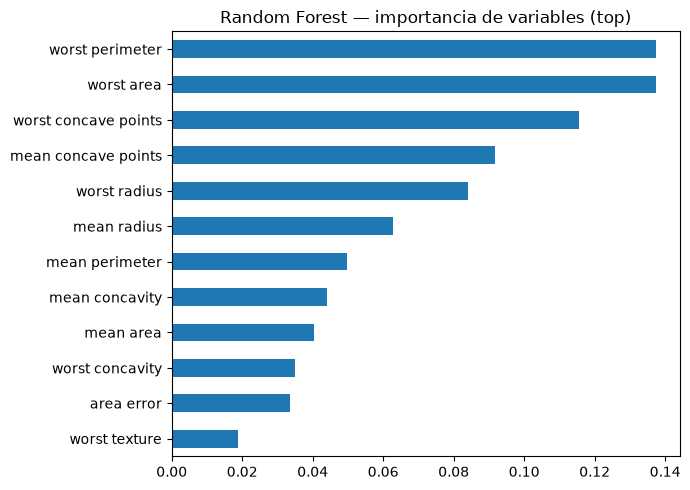

In [6]:

# Importancia de variables según el bosque
rf = RandomForestClassifier(**rf_params).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()[-12:]
imp.plot.barh(figsize=(7,5)); plt.title("Random Forest — importancia de variables (top)")
plt.tight_layout(); plt.show()


## 4. Las tres librerías de gradient boosting

Las tres minimizan un objetivo regularizado de la forma:

$$
\mathcal{L} = \sum_i \ell(y_i, \hat y_i) + \sum_k \Omega(f_k),\qquad
\Omega(f) = \gamma T + \tfrac{1}{2}\lambda \|w\|^2,
$$

(pérdida + penalización de complejidad sobre cada árbol $f_k$ con $T$ hojas y
pesos de hoja $w$). Se diferencian en **cómo crecen los árboles** y en **cómo
manejan los datos y las categorías**.


In [1]:

import xgboost as xgb
from xgboost import XGBClassifier
xgb_params = {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4,
              "subsample": 0.9, "colsample_bytree": 0.9,
              "reg_lambda": 1.0, "eval_metric": "logloss",
              "random_state": 42, "n_jobs": -1}
m_xgb = score_and_log(XGBClassifier(**xgb_params), "XGBoost", xgb_params, flavor="xgboost")


NameError: name 'score_and_log' is not defined

In [ ]:

from lightgbm import LGBMClassifier
lgb_params = {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31,
              "subsample": 0.9, "colsample_bytree": 0.9,
              "reg_lambda": 1.0, "random_state": 42, "n_jobs": -1, "verbose": -1}
m_lgb = score_and_log(LGBMClassifier(**lgb_params), "LightGBM", lgb_params, flavor="lightgbm")


In [ ]:

from catboost import CatBoostClassifier
cat_params = {"iterations": 300, "learning_rate": 0.05, "depth": 4,
              "l2_leaf_reg": 3.0, "random_seed": 42, "verbose": False}
m_cat = score_and_log(CatBoostClassifier(**cat_params), "CatBoost", cat_params, flavor="catboost")


## 5. En qué se diferencian XGBoost, LightGBM y CatBoost

| Aspecto | **XGBoost** | **LightGBM** | **CatBoost** |
|---|---|---|---|
| Crecimiento del árbol | **Por niveles (depth-wise)** — crece todos los nodos de un nivel | **Por hoja (best-first)** — divide la hoja de mayor ganancia | Árboles **simétricos / oblivious** — misma variable+umbral por nivel |
| Búsqueda de splits | Pre-ordenado e **histograma aproximado** | **Histograma** de las variables | Histograma (oblivious) |
| Aceleración en big-data | Consciente de esparsidad, weighted quantile sketch | **GOSS** + **EFB** (bundling de variables exclusivas) | Ordered boosting sobre permutaciones |
| Variables categóricas | Necesitan encoding (one-hot / ordinal) | Soporte nativo (codificadas como enteros) | **Nativo**, con **target statistics ordenadas** (sin fuga) |
| Control de sobreajuste | $\gamma$, $\lambda$, `max_depth`, subsample | num_leaves, min_data_in_leaf, bagging | ordered boosting reduce el sesgo de **prediction shift** |
| Mejor cuando | default robusto, tabular, tamaño medio | **datasets grandes**, muchas variables, velocidad | **muchas categóricas**, buenos defaults |

**En palabras:**
- **XGBoost** popularizó el gradient boosting *regularizado*. Crece los árboles
  **por niveles** y añade la penalización $\Omega$, más shrinkage y submuestreo de
  columnas. Un default sólido y robusto.
- **LightGBM** crece los árboles **por hoja** (siempre la de mayor ganancia), lo
  que da árboles más profundos y precisos por iteración pero puede sobreajustar en
  datos pequeños — contrólalo con `num_leaves`/`min_data_in_leaf`. Usa
  **histogramas** más **GOSS** (mantener ejemplos de gradiente alto, submuestrear
  los de gradiente bajo) y **EFB** (agrupar variables esparsas mutuamente
  excluyentes), siendo muy **rápido en datos grandes y de alta dimensión**.
- **CatBoost** ataca dos problemas: (1) la **fuga de información** al codificar
  categóricas —resuelta con **target statistics ordenadas** sobre permutaciones
  aleatorias—; y (2) el **prediction shift** del boosting estándar —resuelto con
  **ordered boosting**. Usa **árboles simétricos (oblivious)**, rápidos de evaluar
  y que actúan como regularización. Mejor con **muchas variables categóricas**.


## 6. Tabla comparativa y registro del mejor

In [ ]:

bench = pd.DataFrame({"DecisionTree": m_tree, "Bagging-tree": m_bag,
                      "RandomForest": m_rf, "XGBoost": m_xgb,
                      "LightGBM": m_lgb, "CatBoost": m_cat}).T
bench = bench[["accuracy", "f1", "roc_auc"]].sort_values("roc_auc", ascending=False)
display(bench.style.background_gradient(cmap="Greens"))


In [ ]:

bench["roc_auc"].plot.barh(figsize=(7,4)); plt.xlim(0.95, 1.0)
plt.title("ROC-AUC por ensemble en el test de breast cancer")
plt.tight_layout(); plt.show()


In [ ]:

register_best_run("module2-02-ensembles", metric="roc_auc",
                  registered_model_name="breast-cancer-ensemble", mode="max")


## 7. Clasificadores por votación: el meta-ensemble más simple

Antes del combinador aprendido del stacking, la forma más simple de combinar
varios estimadores base **ya entrenados y diversos** es **votar**. No hay
meta-modelo: la regla de combinación es **fija**.

### Voto duro (mayoría)
Cada clasificador base emite un voto y el ensemble predice la clase más común:
$$
\hat y = \operatorname{moda}\{c_1(x),\, c_2(x),\, \dots,\, c_M(x)\}.
$$

### Voto suave (promedio de probabilidades)
Se promedian las probabilidades por clase (opcionalmente con pesos $w_m$) y se
toma el arg-máx:
$$
\hat y = \arg\max_k \sum_{m=1}^{M} w_m\, p_{m,k}(x).
$$
El voto suave suele ganar al duro porque usa la *confianza*, no sólo la etiqueta
ganadora — pero requiere `predict_proba` razonablemente **calibrado** (p. ej.
envolver `SVC` con `probability=True`). Los pesos permiten confiar más en los
modelos fuertes.

### Por qué importa la diversidad
La votación sólo ayuda si los aprendices base cometen **errores decorrelacionados**:
si todos fallan en las mismas filas, promediar no cambia nada. Combinar un RF
basado en árboles, un SVC de margen y un modelo lineal logístico hace que los
errores se cancelen en parte.

### En qué difiere la votación del stacking y del bagging
- **vs stacking:** la votación usa una regla **fija** (moda / promedio
  ponderado); el stacking *aprende* un meta-modelo sobre las predicciones base.
- **vs bagging:** el bagging re-muestrea el **mismo** algoritmo sobre muestras
  bootstrap; la votación combina algoritmos **distintos** sobre todos los datos.


In [ ]:

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Aprendices base diversos. Los sensibles a la escala (LogReg, SVC) van en
# pipelines con StandardScaler, igual que en la sección de Stacking de abajo.
vote_estimators = [
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    ("rf", RandomForestClassifier(n_estimators=300, max_features="sqrt",
                                  random_state=42, n_jobs=-1)),
    ("svc", make_pipeline(StandardScaler(),
                          SVC(C=1.0, kernel="rbf", probability=True, random_state=42))),
]

# Voto duro: mayoría sobre las etiquetas predichas.
vote_hard = VotingClassifier(estimators=vote_estimators, voting="hard", n_jobs=-1)


In [ ]:

# VotingClassifier con voting="hard" no tiene predict_proba, así que score_and_log
# (que necesita probabilidades) no se puede reusar tal cual. Lo puntuamos directo
# y registramos la ejecución con los mismos helpers.
vote_hard.fit(X_train, y_train)
hard_pred = vote_hard.predict(X_test)
m_vote_hard = {"accuracy": accuracy_score(y_test, hard_pred),
               "f1": f1_score(y_test, hard_pred),
               "roc_auc": np.nan}  # indefinido: el voto duro da etiquetas, no probs
log_and_register(run_name="Voting-hard",
                 params={"voting": "hard", "base_learners": "lr+rf+svc"},
                 metrics={"accuracy": m_vote_hard["accuracy"], "f1": m_vote_hard["f1"]},
                 model=vote_hard, flavor="sklearn", tags={"algo": "Voting-hard"})
print(f"{'Voting-hard':14s} | acc {m_vote_hard['accuracy']:.4f} | "
      f"f1 {m_vote_hard['f1']:.4f} | auc   n/a")


In [ ]:

# Voto suave: promedia las probabilidades predichas. Reusa score_and_log porque
# expone predict_proba.
vote_soft = VotingClassifier(estimators=vote_estimators, voting="soft", n_jobs=-1)
m_vote_soft = score_and_log(vote_soft, "Voting-soft",
                            {"voting": "soft", "base_learners": "lr+rf+svc"})

# Voto suave ponderado: apoyarse más en los aprendices fuertes (RF + SVC).
vote_soft_w = VotingClassifier(estimators=vote_estimators, voting="soft",
                               weights=[1, 2, 2], n_jobs=-1)
m_vote_soft_w = score_and_log(vote_soft_w, "Voting-soft-weighted",
                              {"voting": "soft", "weights": "1,2,2",
                               "base_learners": "lr+rf+svc"})


In [ ]:

# Comparamos las variantes de votación con sus propios aprendices base y con los
# modelos de boosting.
from sklearn.base import clone

vote_base_scores = {}
for bname, bmodel in vote_estimators:
    clf = clone(bmodel).fit(X_train, y_train)
    bproba = clf.predict_proba(X_test)[:, 1]
    bpred = (bproba >= 0.5).astype(int)
    vote_base_scores[bname] = {"accuracy": accuracy_score(y_test, bpred),
                               "f1": f1_score(y_test, bpred),
                               "roc_auc": roc_auc_score(y_test, bproba)}

vote_cmp = pd.DataFrame({**vote_base_scores,
                         "Voting-hard": m_vote_hard,
                         "Voting-soft": m_vote_soft,
                         "Voting-soft-weighted": m_vote_soft_w,
                         "XGBoost": m_xgb, "LightGBM": m_lgb,
                         "CatBoost": m_cat}).T
vote_cmp = vote_cmp[["accuracy", "f1", "roc_auc"]].sort_values("f1", ascending=False)

best_single_f1 = max(v["f1"] for v in vote_base_scores.values())
print(f"Mejor F1 de un base individual: {best_single_f1:.4f} | "
      f"F1 Voting-soft: {m_vote_soft['f1']:.4f}")
display(vote_cmp.style.background_gradient(cmap="Purples"))


In [ ]:

# Los runs de voto suave se registraron con roc_auc, así que re-ejecutar la
# promoción del registry elige un modelo de votación si ahora supera a los demás.
register_best_run("module2-02-ensembles", metric="roc_auc",
                  registered_model_name="breast-cancer-ensemble", mode="max")


## 8. Stacking y blending: el pilar del combinador aprendido

El bagging promedia aprendices **independientes** (varianza$\downarrow$) y el
boosting encadena aprendices **secuenciales** (sesgo$\downarrow$). El
**stacked generalization** (stacking) va más allá de la votación de regla fija:
entrena varios **aprendices base diversos** y luego un **meta-aprendiz** que
aprende *cómo combinar sus predicciones*.

### Por qué funciona
Un promedio simple trata a todos los modelos igual. Un meta-aprendiz, en cambio,
aprende **pesos guiados por los datos** (e incluso combinaciones no lineales)
sobre las salidas de los modelos base. La ganancia viene de la **decorrelación de
errores**: si los modelos base cometen errores *distintos*, se cancelan en parte,
y el meta-aprendiz se apoya en el modelo fiable en cada región. Si todos los
modelos base fueran idénticos, el stacking no aportaría nada — **la diversidad es
el combustible**.

### La trampa de la fuga → predicciones out-of-fold (OOF)
El meta-aprendiz debe entrenarse con predicciones de los modelos base sobre
ejemplos que estos **no vieron durante su entrenamiento**. Si los entrenáramos
sobre todo el set y luego les diéramos sus predicciones *in-sample*, estas serían
demasiado optimistas (ya "vieron la respuesta"), el meta-aprendiz sobreajustaría
y el rendimiento en test colapsaría. La solución son las **predicciones
out-of-fold (OOF)** vía $k$-fold:

1. Dividir el set de entrenamiento en $k$ folds.
2. Para cada fold, entrenar los modelos base en los otros $k-1$ folds y predecir
   el fold retenido. Concatenando se obtiene una **predicción OOF limpia por
   fila** — ninguna fila la predijo un modelo que se entrenó con ella.
3. Entrenar el meta-aprendiz sobre la matriz OOF $Z \in \mathbb{R}^{n \times M}$
   (filas = ejemplos, columnas = $M$ modelos base).
4. Re-entrenar cada modelo base con **todo** el set para inferir sobre datos
   nuevos.

$$
\hat y = g\big(f_1(x),\, f_2(x),\, \dots,\, f_M(x)\big),
$$

donde $f_m$ son los aprendices base y $g$ el meta-aprendiz entrenado sobre $Z$.

### Blending vs stacking
- **Stacking** usa predicciones **OOF** de $k$-fold — cada fila contribuye a las
  meta-features, así que es eficiente en datos (pero entrena los base $k$ veces).
- **Blending** usa un único **holdout**: los base entrenan en la parte A, el
  meta-aprendiz entrena con sus predicciones para una parte B retenida. Más simple
  y rápido, pero el meta-aprendiz ve menos filas.

El `StackingClassifier` de scikit-learn implementa la variante de stacking: pasar
`cv=5` genera las meta-features con OOF de 5 folds internamente.


In [ ]:

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Aprendices base diversos: un ensemble de árboles embolsado, un clasificador de
# margen y uno basado en distancia. SVC/kNN necesitan escalado → pipelines.
base_estimators = [
    ("rf", RandomForestClassifier(n_estimators=300, max_features="sqrt",
                                  random_state=42, n_jobs=-1)),
    ("svc", make_pipeline(StandardScaler(),
                          SVC(C=1.0, kernel="rbf", probability=True, random_state=42))),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))),
]

# Meta-aprendiz de regresión logística entrenado con predicciones OOF de 5 folds.
stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1,
)
stack_params = {"final_estimator": "LogisticRegression", "cv": 5,
                "base_learners": "rf+svc+knn", "stack_method": "predict_proba"}
m_stack = score_and_log(stack, "Stacking", stack_params)


In [ ]:

# ¿Cómo se compara el stacking con sus propios aprendices base y los de boosting?
# (Puntuamos cada base por separado para una comparación justa.)
from sklearn.base import clone

base_scores = {}
for bname, bmodel in base_estimators:
    clf = clone(bmodel).fit(X_train, y_train)
    bproba = clf.predict_proba(X_test)[:, 1]
    bpred = (bproba >= 0.5).astype(int)
    base_scores[bname] = {"accuracy": accuracy_score(y_test, bpred),
                          "f1": f1_score(y_test, bpred),
                          "roc_auc": roc_auc_score(y_test, bproba)}

stack_cmp = pd.DataFrame({**base_scores,
                          "Stacking": m_stack,
                          "XGBoost": m_xgb, "LightGBM": m_lgb,
                          "CatBoost": m_cat}).T
stack_cmp = stack_cmp[["accuracy", "f1", "roc_auc"]].sort_values("f1", ascending=False)

best_single_f1 = max(v["f1"] for v in base_scores.values())
print(f"Mejor F1 de un base individual: {best_single_f1:.4f} | "
      f"F1 Stacking: {m_stack['f1']:.4f}")
display(stack_cmp.style.background_gradient(cmap="Blues"))


In [ ]:

# El stacking se registró como un run del mismo experimento, así que re-ejecutar
# la promoción del registry lo elige si ahora tiene el mejor ROC-AUC.
register_best_run("module2-02-ensembles", metric="roc_auc",
                  registered_model_name="breast-cancer-ensemble", mode="max")


## 9. Resumen

| Familia | Método(s) | Idea central | Reduce |
|---|---|---|---|
| **Bagging** | BaggingClassifier / Random Forest | promediar árboles independientes y decorrelacionados | varianza |
| **Boosting** | XGBoost / LightGBM / CatBoost | corregir residuos secuencialmente | sesgo (+varianza) |
| **Meta-ensembling** | **Voting** y **Stacking** | combinar aprendices base diversos | error residual |

- **Bagging** (Random Forest) reduce la **varianza** con árboles independientes y
  decorrelacionados — vergonzosamente paralelo.
- **Boosting** reduce el **sesgo** corrigiendo residuos en secuencia.
- Las tres librerías de boosting comparten el objetivo GBM regularizado pero
  difieren en **crecimiento del árbol** (niveles / hoja / simétrico), **trucos de
  velocidad** (GOSS+EFB) y **manejo de categóricas** (target statistics ordenadas).
- El **meta-ensembling** combina aprendices **diversos**. La **votación** usa una
  regla **fija** — mayoría (duro) o promedio ponderado de probabilidades (suave);
  el **stacking** entrena un **meta-aprendiz** sobre predicciones **out-of-fold**
  para evitar la fuga, con el **blending** como variante holdout más barata.
- Elige **LightGBM** para datos grandes, **CatBoost** para muchas categóricas,
  **XGBoost** como default robusto, empieza el meta-ensembling con **votación** y
  recurre al **stacking** para exprimir el último punto — siempre con MLflow.
